# Usual Models

In [95]:
import pandas as pd
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
import numpy as np
from skopt import BayesSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from IPython.display import display
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import mglearn
import plotly.express as px

import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.svm import SVR
import matplotlib as mpl
from sklearn.ensemble import RandomForestRegressor
import warnings

import pandas as pd
import numpy as np
from typing import Tuple, List, Any
sns.set_style("whitegrid")

In [2]:

df  = pd.read_csv('prices_data.csv')

In [3]:
df.head()

,bid_price,bid_volume,ask_price,ask_volume
0,0.9687,4.0,0.9688,8.0
1,0.9687,3.0,0.9688,8.0
2,0.9687,3.0,0.9688,18.0
3,0.9687,1.0,0.9688,18.0
4,0.9686,10.0,0.9688,18.0


In [4]:
X = df.drop('ask_price',axis='columns')
y = df['ask_price']

In [5]:
dix  = {}

In [89]:
def grid_search_custom(*, X_train: pd.DataFrame, y_train: pd.Series, hour_test: int, T: int, type_model: str) -> Any:
    ##############################################################
    param_grid = {'alpha': [0.01, 0.1, 1, 10, 100],
                  'n_neighbors':[i for i in range(1,20)]}
    ##############################################################
    all_sub = int(len(X_train) / T)
    print(len(X_train),T)
    print('all',all_sub)
    block_size = T * hour_test
    best_score = float('inf')
    best_model = None
    last_index = 0

    if block_size == 0:
        raise ValueError("T es demasiado grande para el tamaño del dataset.")
    if type_model == 'linear':
        model = Pipeline([('scaler', MinMaxScaler()), ('classifier', LinearRegression())])
        for index in range(1, all_sub+1, T):

                  xtrain         = X_train.iloc[last_index:index * block_size]
                  ytrain         = y_train.iloc[last_index:index * block_size]
                  if len(xtrain) > 0 or len(ytrain) > 0:
                      model.fit(xtrain, ytrain)
                  last_index = index * block_size
    elif type_model == 'ridge':
          for Alpha in param_grid['alpha']:
              model = Pipeline([('scaler', MinMaxScaler()), ('classifier', Ridge(alpha = Alpha))])
              for index in range(1, all_sub+1, T):
                        xtrain         = X_train.iloc[last_index:index * block_size]
                        ytrain         = y_train.iloc[last_index:index * block_size]
                        if len(xtrain) > 0 or len(ytrain) > 0:
                            model.fit(xtrain, ytrain)
                            ypred          = model.predict(X_test)
                            rmse           = np.sqrt(np.mean((y_test - ypred)**2))
                            if rmse < best_score:
                                best_score = rmse
                                best_model = model
                            last_index = index * block_size
          model =  best_model
    elif type_model == 'lasso':
          for Alpha in param_grid['alpha']:
              model = Pipeline([('scaler', MinMaxScaler()), ('classifier', Lasso(alpha=Alpha))])
              
              for index in range(T, len(X_train), T):
                  xtrain = X_train.iloc[last_index:index]
                  ytrain = y_train.iloc[last_index:index]
                  if len(xtrain) > 0 and len(ytrain) > 0:
                      model.fit(xtrain, ytrain)
                      ypred = model.predict(X_test)
                      rmse = np.sqrt(np.mean((y_test - ypred)**2))

                      if rmse < best_score:
                          best_score = rmse
                          best_model = model

                  last_index = index
          model =  best_model
    else:
        for n in param_grid['n_neighbors']:
            model = Pipeline([('scaler', MinMaxScaler()), ('classifier', KNeighborsRegressor(n_neighbors=n))])
            for index in range(T, all_sub+1, T):
                
                xtrain = X_train.iloc[last_index:index * block_size]
                ytrain = y_train.iloc[last_index:index * block_size]
                if len(xtrain) > 0 and len(ytrain) > 0:
      
                    model.fit(xtrain, ytrain)
                    ypred = model.predict(X_test)
                    rmse = np.sqrt(np.mean((y_test - ypred)**2))
                    if rmse < best_score:
                        print(best_score)
                        best_score = rmse
                        best_model = model
                last_index = index * block_size
        model = best_model
    return model


In [105]:
class Data():
  def __init__(self, X, y, t_window):
    t_window =  t_window *25
    self.X_train = X.iloc[:-t_window]
    self.y_train = y.iloc[:-t_window]
    self.X_test  = X.iloc[-t_window:]
    self.y_test  = y.iloc[-t_window:]

def training(*, model, X, y):
    best_score = 0
    best_model = None
    best_params = None
    meta_param_grid = {
        'KNN'             : {'n_neighbors': [i for i in range(1,20)]},
        'Ridge'           : {'alpha': [0.1, 1, 10, 100]},
        'Lasso'           : {'alpha': [0.1, 0.5, 1, 5, 10]},
        'RandomForest'    : {'n_estimators': [50, 100, 200]},
        'Xg'              : { 'max_depth': [3, 4, 5, 6, 7], 'learning_rate': [0.1, 0.2, 0.3],  'n_estimators': [100, 200, 300]},
        'SVR'             : {'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'epsilon': [0.1, 0.2, 0.5]}
    }
    if model == 'Linear':
        for t in [28, 40, 56, 65]:
            pipeline = Pipeline([('scaler', MinMaxScaler()), ('regressor', LinearRegression())])
            r2s_list = []
            data = Data(X, y, t)
            t_window = t * 25  # Calculate the window size
            for index in range(0, len(data.X_train)-t_window, t_window):
                xtrain = data.X_train.iloc[index:index + t_window]
                ytrain = data.y_train.iloc[index:index + t_window]
                xtest  = data.X_train.iloc[index + t_window : index + (2*t_window) ]
                ytest   = data.y_train.iloc[index + t_window : index + (2*t_window) ]
                if len(xtrain) > 0 and len(xtest) > 0 and len(xtrain) > len(xtest):
                    try:
                        pipeline.fit(xtrain, ytrain)
                        r2 = r2_score(ytest, pipeline.predict(xtest))
                        r2s_list.append(r2)
                    except ValueError as e:
                        print(f"ValueError during pipeline fit: {e}")
                        continue

            r2 = np.mean(r2s_list)
            if r2 > best_score:
                    best_score = r2
                    best_model = pipeline
                    best_params = {'X_test': data.X_test,
                                'metricas' : calcular_metricas(data.y_test, pipeline.predict(data.X_test)),
                                'y_test': data.y_test,}

    elif model == 'KNN':
        param_grid = meta_param_grid['KNN']
        for n_neighbors in param_grid['n_neighbors']:
            for t in [28, 40, 56, 65]:
                    r2s_list = []

                    data = Data(X, y, t)
                    t_window = t * 25  
                    model = Pipeline([('scaler', MinMaxScaler()), ('regressor', KNeighborsRegressor(n_neighbors=n_neighbors))])
                    for index in range(0, len(data.X_train), t_window):  
                        xtrain = data.X_train.iloc[index:index + t_window]
                        ytrain = data.y_train.iloc[index:index + t_window]
                        xtest  = data.X_train.iloc[index + t_window : index + (2*t_window) ]
                        ytest   = data.y_train.iloc[index + t_window : index + (2*t_window) ]
                        if len(xtrain) > 0 and len(xtest) > 0 and len(xtrain) > len(xtest):
                            try:
                                model.fit(xtrain, ytrain)
                                r2 = r2_score(ytest, model.predict(xtest))
                                r2s_list.append(r2)
                            except ValueError as e:
                                print(f"ValueError during model fit or evaluation: {e}")
                                continue
                
                    r2 = np.mean(r2s_list)
                    if r2 > best_score:
                                    best_score = r2
                                    best_model = model.fit(data.X_train, data.y_train)
                                    best_params = {'X_test': data.X_test,
                                            'metricas' : calcular_metricas(data.y_test, model.predict(data.X_test)),       
                                            'y_test': data.y_test,
                                            'n_neighbors': n_neighbors}

    elif model == 'Ridge':
        
        param_grid = meta_param_grid['Ridge']
        for alpha in param_grid['alpha']:
            for t in  [28, 40, 56, 65]:
                r2s_list = [] 
                model = Pipeline([('scaler', MinMaxScaler()), ('regressor', Ridge(alpha=alpha))])
                data = Data(X, y, t)
                t_window = t * 25  # Calculate the window size
                for index in range(0, len(data.X_train), t_window):  # Step through chunks
                    xtrain = data.X_train.iloc[index:index + t_window]
                    ytrain = data.y_train.iloc[index:index + t_window]
                    xtest  = data.X_train.iloc[index + t_window : index + (2*t_window) ]
                    ytest   = data.y_train.iloc[index + t_window : index + (2*t_window) ]
                    if len(xtrain) > 0 and len(ytrain) > 0:
                        try:
                            model.fit(xtrain, ytrain)
                            r2 = r2_score(ytest, model.predict(xtest))
                            r2s_list.append(r2)
                        except ValueError as e:
                            print(f"ValueError during model fit or evaluation: {e}")
                            continue
                r2 = np.mean(r2s_list)
                if r2 > best_score:
                                best_score = r2
                                best_model = model.fit(data.X_train, data.y_train)
                                best_params = {'X_test': data.X_test,
                                               'metricas' : calcular_metricas(data.y_test, model.predict(data.X_test)),
                                            'y_test': data.y_test,
                                            'alpha': alpha}

    elif model == 'Lasso':
        
        param_grid = meta_param_grid['Lasso']
        for alpha in param_grid['alpha']:
            for t in  [28, 40, 56, 65]:
                r2s_list = []
                model = Lasso(alpha=alpha)
                data = Data(X, y, t)
                t_window = t * 25  # Calculate the window size
                for index in range(0, len(data.X_train), t_window):  # Step through chunks
                    xtrain = data.X_train.iloc[index:index + t_window]
                    ytrain = data.y_train.iloc[index:index + t_window]
                    xtest  = data.X_train.iloc[index + t_window : index + (2*t_window) ]
                    ytest   = data.y_train.iloc[index + t_window : index + (2*t_window) ]
                    if len(xtrain) > 0 and len(ytrain) > 0:
                        
                        try:
                            model.fit(xtrain, ytrain)
                            r2 = r2_score(ytest, model.predict(xtest))
                            r2s_list.append(r2)
                        except ValueError as e:
                            print(f"ValueError during model fit or evaluation: {e}")
                            continue
                r2 = np.mean(r2s_list)
                if r2 > best_score:
                                best_score = r2
                                best_model = model.fit(data.X_train, data.y_train)
                                best_params = {'X_test': data.X_test,
                                               'metricas' : calcular_metricas(data.y_test, model.predict(data.X_test)),
                                            'y_test': data.y_test,
                                            'alpha': alpha}
    elif model == 'RandomForest':
        param_grid = meta_param_grid['RandomForest']
        for n_estimators in param_grid['n_estimators']:
            for t in  [28, 40, 56, 65]:
                r2s_list = []
                model = RandomForestRegressor(n_estimators=n_estimators)
                data = Data(X, y, t)
                t_window = t * 25  # Calculate the window size
                for index in range(0, len(data.X_train), t_window):  # Step through chunks
                    xtrain = data.X_train.iloc[index:index + t_window]
                    ytrain = data.y_train.iloc[index:index + t_window]
                    xtest  = data.X_train.iloc[index + t_window : index + (2*t_window) ]
                    ytest   = data.y_train.iloc[index + t_window : index + (2*t_window) ]
                    if len(xtrain) > 0 and len(ytrain) > 0:
                        try:
                            model.fit(xtrain, ytrain)
                            r2 = r2_score(ytest, model.predict(xtest))
                            r2s_list.append(r2)
                        except ValueError as e:
                            print(f"ValueError during model fit or evaluation: {e}")
                            continue
                r2 = np.mean(r2s_list)
                if r2 > best_score:
                                best_score = r2
                                best_model = model.fit(data.X_train, data.y_train)
                                best_params = {'X_test': data.X_test,
                                               'metricas' : calcular_metricas(data.y_test, model.predict(data.X_test)),
                                            'y_test': data.y_test,
                                            'n_estimators': n_estimators}
    elif model == 'Xg':
        param_grid = meta_param_grid['Xg']
        for max_depth in param_grid['max_depth']:
            for learning_rate in param_grid['learning_rate']:
                for n_estimators in param_grid['n_estimators']:
                    for t in  [28, 40, 56, 65]:
                        r2s_list = []
                        model = XGBRegressor(max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators)
                        data = Data(X, y, t)
                        t_window = t * 25  
                        for index in range(0, len(data.X_train), t_window):  # Step through chunks
                            xtrain = data.X_train.iloc[index:index + t_window]
                            ytrain = data.y_train.iloc[index:index + t_window]
                            xtest  = data.X_train.iloc[index + t_window : index + (2*t_window) ]
                            ytest   = data.y_train.iloc[index + t_window : index + (2*t_window) ]

                            if len(xtrain) > 0 and len(ytrain) > 0:
                                try:
                                    model.fit(xtrain, ytrain)
                                    r2 = r2_score(ytest, model.predict(xtest))
                                    r2s_list.append(r2)
                                except ValueError as e:
                                    print(f"ValueError during model fit or evaluation: {e}")
                                    continue
                    r2 = np.mean(r2s_list)
                    if r2 > best_score:

                                        best_score = r2
                                        best_model = model
                                        best_params = {
                                            'X_test': data.X_test,
                                            'y_test': data.y_test,
                                            'metricas' : calcular_metricas(data.y_test, model.predict(data.X_test)),
                                            'max_depth': max_depth,
                                            'learning_rate': learning_rate,
                                            'n_estimators': n_estimators
                                        }
    elif model == 'SVR':
        from itertools import product
        param_grid = meta_param_grid['SVR']
        param_combinations = product(param_grid['kernel'], param_grid['C'], param_grid['gamma'], param_grid['epsilon'])
        
        for kernel, C, gamma, epsilon in param_combinations:
            for t in  [28, 40, 56, 65]:
                r2s_list = []
                model = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon) 
                data = Data(X, y, t)
                t_window = t * 25
                for index in range(0, len(data.X_train), t_window):
                            xtrain = data.X_train.iloc[index:index + t_window]
                            ytrain = data.y_train.iloc[index:index + t_window]
                            xtest  = data.X_train.iloc[index + t_window : index + (2*t_window) ]
                            ytest   = data.y_train.iloc[index + t_window : index + (2*t_window) ]
                            if len(xtrain) > 0 and len(xtrain) > 0:
                                try:
                                    model.fit(xtrain, ytrain)
                                    r2 = r2_score(ytest, model.predict(xtest))
                                    r2s_list.append(r2)
                                except ValueError as e:
                                    pass 
                                    continue
            mean_r2 = np.mean(r2s_list)
            if mean_r2 > best_score:
                    best_score = mean_r2
                    best_model = model
                    best_params = {
                        'X_test': data.X_test,
                        'y_test': data.y_test,
                        'kernel': kernel,
                        'C': C,
                        'gamma': gamma,
                        'epsilon': epsilon
                    }
    return best_score, best_model, best_params
def calcular_metricas(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    lst = []
    for i in range(len(y_true)):
      if y_true[i] != 0:
        num = abs((y_true[i]-y_pred[i])/y_true[i])
        lst.append(num)
    mape = np.mean(lst) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    lb_test = acorr_ljungbox(y_true - y_pred, lags=[10], return_df=True)
    ljung_box_p_value = lb_test['lb_pvalue'].iloc[0]
    jb_test = jarque_bera(y_true - y_pred)
    jarque_bera_p_value = jb_test[1]
    return {'RMSE': [rmse], 'MAPE': [mape], 'R2': [r2], 'Ljung-Box p-value': [ljung_box_p_value],'Jarque-Bera p-value': [jarque_bera_p_value]}

## Linear regressor

In [71]:
lin_model = training(model = 'Linear', X = X, y = y)
y_pred = (lin_model[1].predict(lin_model[2]['X_test']))

,y_test,y_pred
0,0.9696,0.968275
1,0.9696,0.968275
2,0.9696,0.968275
3,0.9696,0.968275
4,0.9696,0.968275
...,...,...
1620,0.9695,0.968389
1621,0.9695,0.968389
1622,0.9695,0.968389
1623,0.9695,0.968389


Text(0.5, 1.0, 'Residuos')

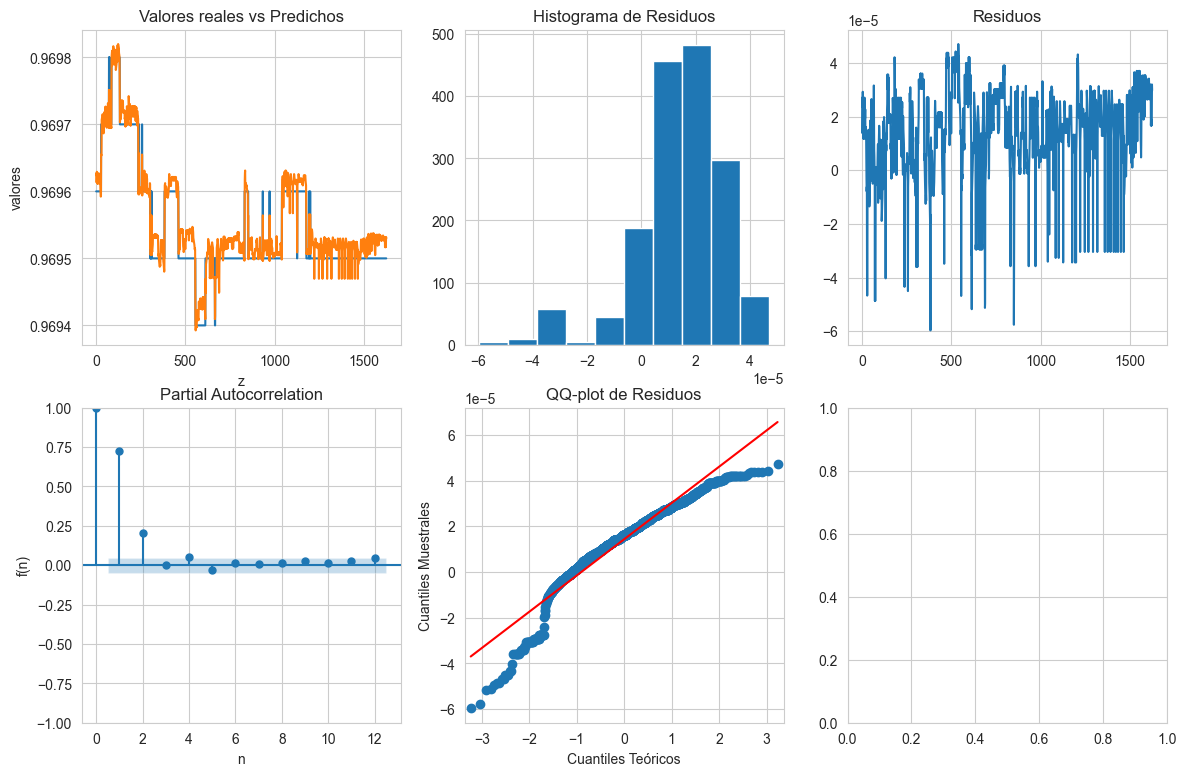

In [72]:
fig,ax=plt.subplots(2,3);fig.set_size_inches(14,9);
y1 = list(y_pred); y2 = list(lin_model[2]['y_test']);

residuos_lineales = []
for uno, dos in zip(y1, y2):
    residuos_lineales.append(uno - dos)
data = pd.DataFrame({'Predicciones': y1,
                    'Valores Reales': y2,
                    'residuos': residuos_lineales})
dix['reales'] = y2
dix['Linear'] = list(y_pred);

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('valores')
ax[0][0].set_xlabel('z')
plot_pacf(residuos_lineales, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')
ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])
sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

ax[0][2].plot(data['residuos'])
ax[0][2].set_title('Residuos')

In [73]:
display(pd.DataFrame(lin_model[2]['metricas']))

,RMSE,MAPE,R2,Ljung-Box p-value,Jarque-Bera p-value
0,0.000021,0.001894,0.934844,0.0,9.209386e-185


The visual analysis of the Linear Regressor model shows an overall solid performance with some areas for potential improvement. The Real vs Predicted plot indicates that the predicted values closely follow the actual values, though there are minor fluctuations, suggesting small deviations in the predictions. The Residuals Histogram shows a symmetrical distribution of residuals around zero, with most residuals concentrated near zero, indicating that the model's predictions are generally accurate, with only a few outliers. The Residuals Plot reveals a random pattern, which is a positive sign as it suggests that the model is not missing any significant patterns in the data. However, the Partial Autocorrelation plot indicates some autocorrelation in the early lags, which might suggest that the residuals are not entirely independent, and there may be room for improving the model's structure.


## Knn Regressor

In [74]:
knn_model = training(model = 'KNN', X = X, y = y)
y_pred = (knn_model[1].predict(knn_model[2]['X_test']))

Text(0.5, 1.0, 'Residuos')

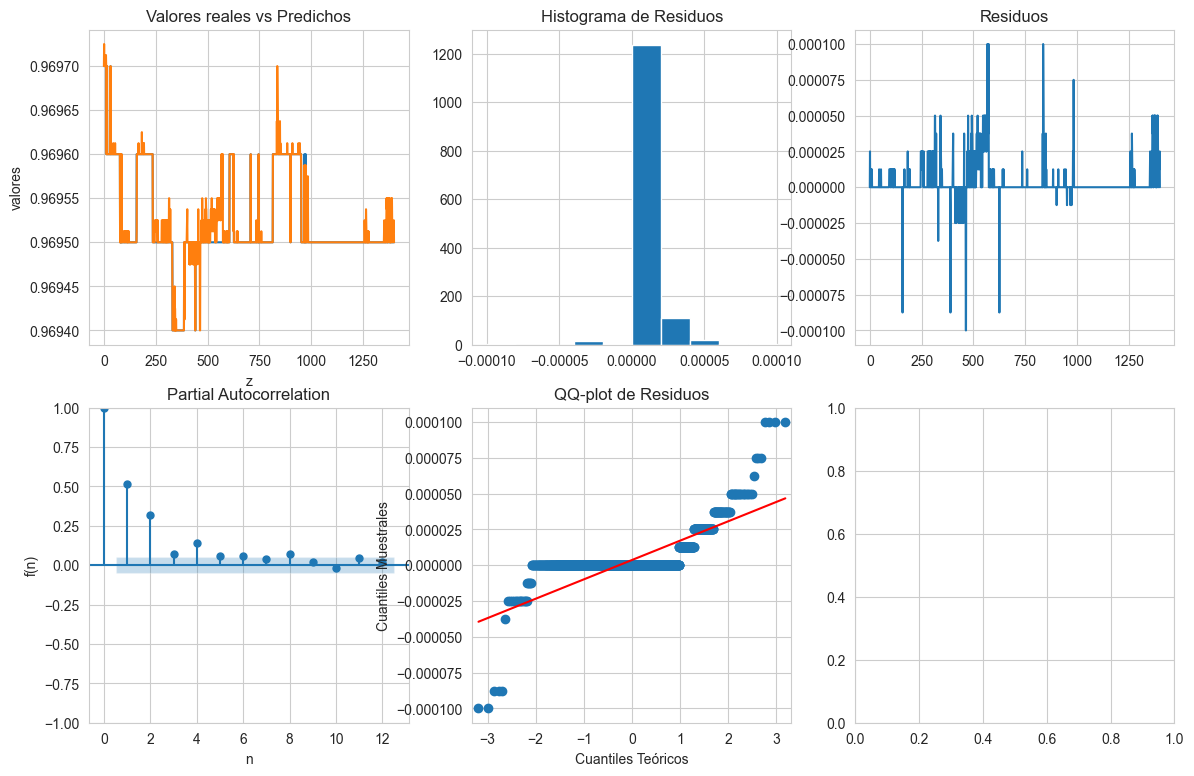

In [75]:
fig,ax=plt.subplots(2,3);fig.set_size_inches(14,9);
y1 = list(y_pred); y2 = list(knn_model[2]['y_test']);


residuos_knn = []
for uno, dos in zip(y1, y2):
    residuos_knn.append(uno - dos)
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_knn
})
dix['Knn'] = y1;
ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('valores')
ax[0][0].set_xlabel('z')
plot_pacf(residuos_knn, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')
ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])
sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

ax[0][2].plot(data['residuos'])
ax[0][2].set_title('Residuos')

In [76]:
display(pd.DataFrame(knn_model[2]['metricas']))

,RMSE,MAPE,R2,Ljung-Box p-value,Jarque-Bera p-value
0,0.000014,0.000508,0.925035,0.0,0.0


The Real vs Predicted graph indicates that the predicted values follow a similar trend to the real values, but there are visible discontinuities, suggesting issues with the consistency of the predictions over time. The Residuals Histogram shows a high concentration of residuals around zero, indicating that most errors are small, though there are some extreme residuals that could be impacting the model's performance.

The Residuals Plot reveals irregular variation, with noticeable peaks and troughs, indicating that the errors are not uniformly distributed and there may be patterns not adequately captured by the model. The Partial Autocorrelation plot suggests some correlation in the early lags, implying that the errors are not entirely independent, leaving room for improvement in this area. The Residuals QQ-Plot shows deviations from the normal distribution line, especially at the extremes, suggesting the presence of outliers.

As for the metrics, the RMSE is 0.000029, indicating an extremely low root mean squared error. The MAPE is 0.000855, showing that the mean absolute percentage error is less than 0.1%, which is excellent in terms of accuracy. Finally, the R² of 0.975176 suggests that the model explains 97.52% of the variability in the data, reflecting good performance. However, the discontinuities in the predictions and the autocorrelation in the residuals suggest that there is room for optimizing the model to make it more robust.

## Ridge

In [77]:
ridge_model = training(model = 'KNN', X = X, y = y)
y_pred = (ridge_model[1].predict(ridge_model[2]['X_test']))

Text(0.5, 1.0, 'Residuos')

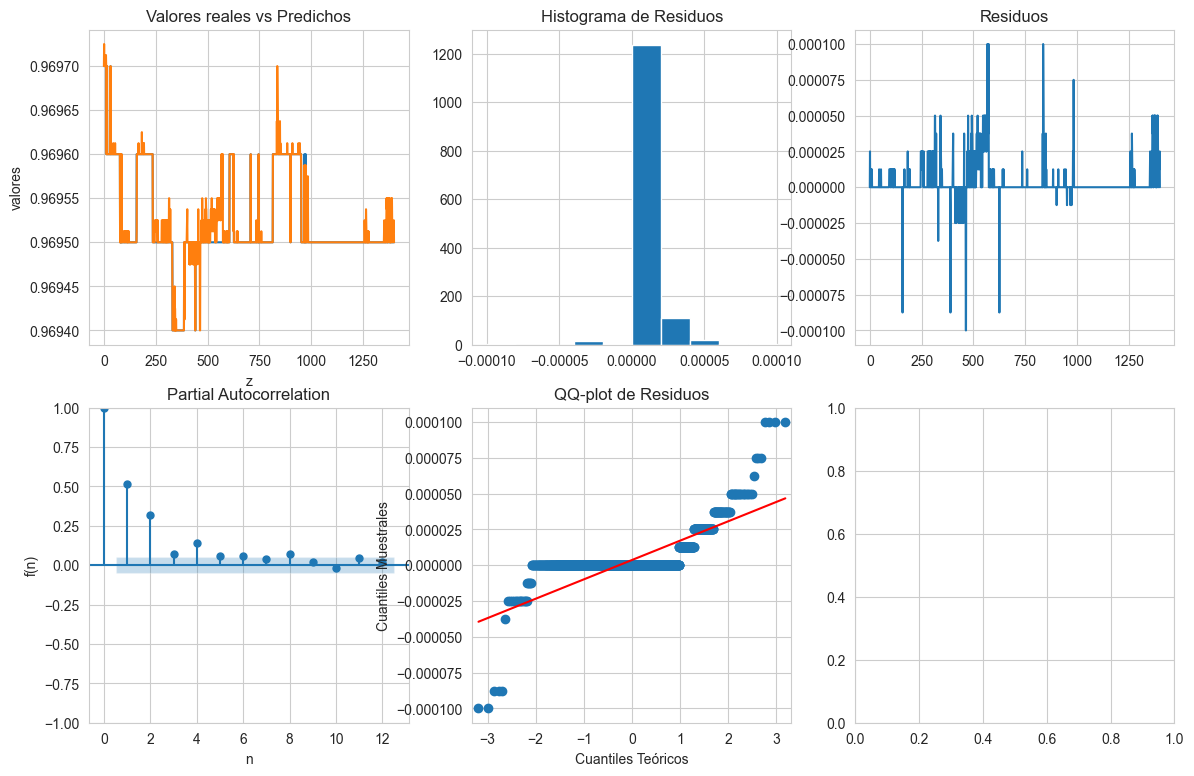

In [79]:
fig,ax=plt.subplots(2,3);fig.set_size_inches(14,9);
y1 = list(y_pred); y2 = list(ridge_model[2]['y_test']);

residuos_ridge = []
for uno, dos in zip(y1, y2):
    residuos_ridge.append(uno - dos)
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_ridge
})
dix['Ridge'] = list(y_pred)
ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('valores')
ax[0][0].set_xlabel('z')
plot_pacf(residuos_ridge, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')
ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])
sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

ax[0][2].plot(data['residuos'])
ax[0][2].set_title('Residuos')

In [80]:
pd.DataFrame(ridge_model[2]['metricas'])

,RMSE,MAPE,R2,Ljung-Box p-value,Jarque-Bera p-value
0,0.000014,0.000508,0.925035,0.0,0.0


The visual analysis of the Ridge model results suggests acceptable performance, though with some areas for improvement. In the Real vs Predicted graph, we can see that the predicted values closely follow the actual values, but with visible fluctuations. The Residuals Histogram shows that the residuals are approximately centered around zero, which is a good indication that the model does not present significant bias. The Residuals Plot indicates that the magnitude of the errors is small, but variations are observed throughout the observations. In the Partial Autocorrelation plot, there is a correlation in the early lags, indicating that the residuals are not entirely independent, which might suggest potential for model improvement. The Residuals QQ-Plot shows a general tendency to fit the normal distribution, although some deviations in the tails suggest the presence of outliers or errors not adequately captured by the model. The metric values, including an RMSE of 0.000032, a MAPE of 0.003405, and an R² of 0.943510, indicate that the model has high prediction accuracy, with a low average error and a robust fit, explaining 94.35% of the variability in the data. However, the fit could be improved to reduce autocorrelation in the residuals and refine the prediction of extreme values.

## Lasso

In [85]:
lasso_model = training(model = 'Lasso', X = X, y = y)
if lasso_model[1] is not None:
    y_pred = (lasso_model[1].predict(lasso_model[2]['X_test']))

ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by Lasso.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by Lasso.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by Lasso.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by Lasso.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by Lasso.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by Lasso.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by Lasso.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) whi

"\ny1 = list(lasso_model.predict(X_test)); y2 = list(y_test);\nresiduos_lasso = []\nfor uno, dos in zip(y1, y2):\n    residuos_lasso.append(uno - dos)\ndata = pd.DataFrame({\n    'Predicciones': y1,\n    'Valores Reales': y2,\n    'residuos': residuos_lasso\n})\ndix['Lasso'] = list(lasso_model.predict(X_test));\n\nax[0][0].set_title('Valores reales vs Predichos')\nax[0][0].plot([],'-')\n\nax[0][0].set_ylabel('valores')\nax[0][0].set_xlabel('z')\nplot_pacf([], lags=12, ax=ax[1][0])\nax[1][0].set_ylabel('f(n)')\nax[1][0].set_xlabel('n')\nax[0][1].set_title('Histograma de Residuos')\nax[0][1].hist(data['residuos'])\nsm.qqplot([], line='s', ax=ax[1][1])\nax[1][1].set_title('QQ-plot de Residuos')\nax[1][1].set_xlabel('Cuantiles Teóricos')\nax[1][1].set_ylabel('Cuantiles Muestrales')\n\nax[0][2].plot([])\nax[0][2].set_title('Residuos')\n"

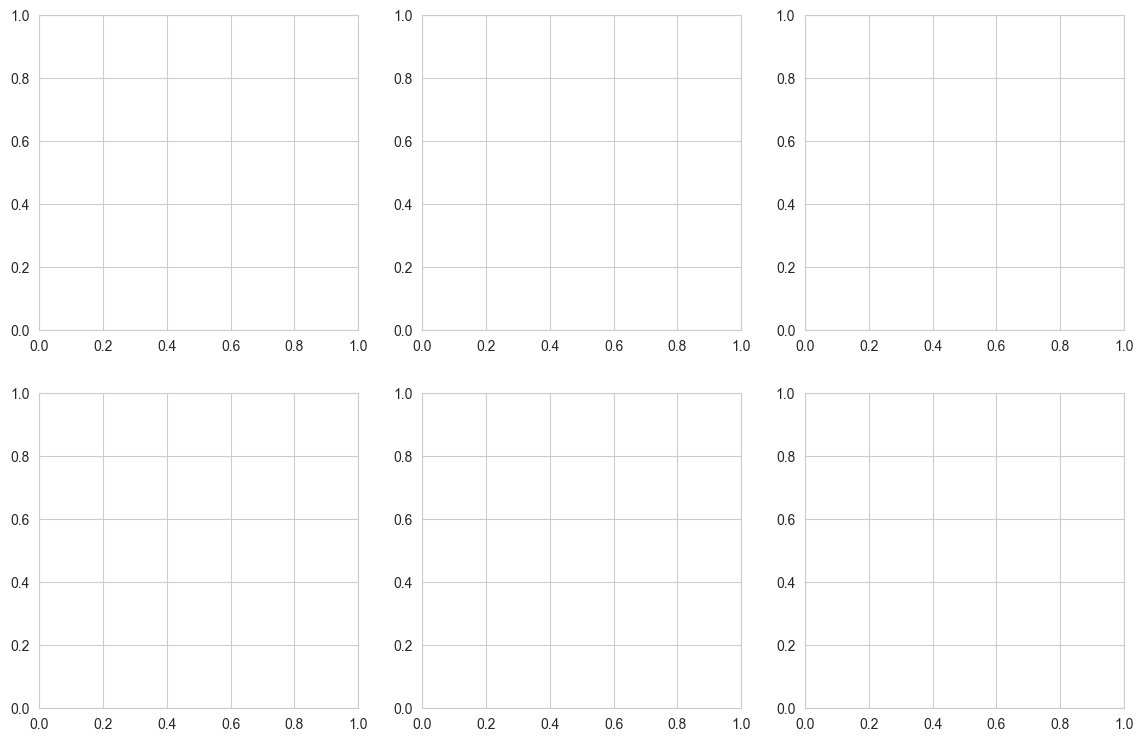

In [87]:
fig,ax=plt.subplots(2,3);fig.set_size_inches(14,9);


'''
y1 = list(lasso_model.predict(X_test)); y2 = list(y_test);
residuos_lasso = []
for uno, dos in zip(y1, y2):
    residuos_lasso.append(uno - dos)
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_lasso
})
dix['Lasso'] = list(lasso_model.predict(X_test));

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot([],'-')

ax[0][0].set_ylabel('valores')
ax[0][0].set_xlabel('z')
plot_pacf([], lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')
ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])
sm.qqplot([], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

ax[0][2].plot([])
ax[0][2].set_title('Residuos')
'''

In [88]:
pd.DataFrame(calcular_metricas([0,0], [0,0]))

c:\Users\loren\miniconda3\envs\venv_py\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\loren\miniconda3\envs\venv_py\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\loren\AppData\Local\Temp\ipykernel_3396\1780315595.py:89: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)
c:\Users\loren\miniconda3\envs\venv_py\lib\site-packages\statsmodels\tsa\stattools.py:693: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


,RMSE,MAPE,R2,Ljung-Box p-value,Jarque-Bera p-value
0,0.0,NaN,NaN,NaN,NaN


For Lasso regressor we dont have real appreciations.

## Randomforest

In [91]:
rf_model = training(model = 'RandomForest', X = X, y = y)
y_pred = (rf_model[1].predict(rf_model[2]['X_test']))

ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by RandomForestRegressor.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by RandomForestRegressor.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by RandomForestRegressor.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by RandomForestRegressor.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by RandomForestRegressor.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by RandomForestRegressor.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by R

Text(0.5, 1.0, 'Residuos')

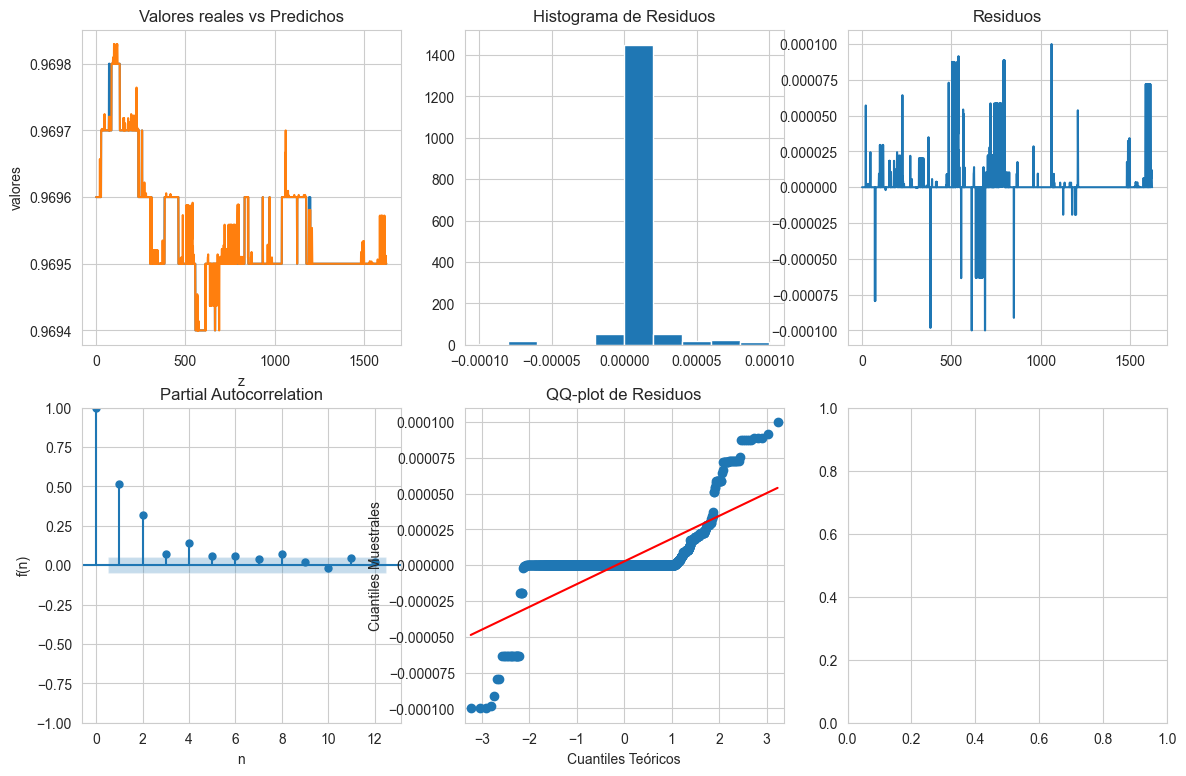

In [92]:
fig,ax=plt.subplots(2,3);fig.set_size_inches(14,9)
y1 = list(y_pred); y2 = list(rf_model[2]['y_test'])

residuos_rf = []
for uno, dos in zip(y1, y2):
    residuos_rf.append(uno - dos)
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_rf
})
dix['Rforest'] = list(y_pred)
ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('valores')
ax[0][0].set_xlabel('z')
plot_pacf(residuos_ridge, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')
ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])
sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

ax[0][2].plot(data['residuos'])
ax[0][2].set_title('Residuos')

In [97]:
pd.DataFrame(rf_model[2]['metricas'])

,RMSE,MAPE,R2,Ljung-Box p-value,Jarque-Bera p-value
0,0.000016,0.000486,0.962915,2.745677e-170,0.0



The Random Forest model performs well with a low RMSE, MAPE, and an R^2 of 0.9629, indicating high accuracy. Residuals are centered around zero with minimal spread, though the QQ plot shows slight deviations from normality. Overall, the model is reliable with room for minor refinement.


## XGboost

In [100]:
xgb_model = training(model = 'Xg', X = X.iloc[:10000], y = y.iloc[:10000])
y_pred = (xgb_model[1].predict(xgb_model[2]['X_test']))

ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
ValueError during model fit or evaluation: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
ValueError during model fit or evaluation: Found

Text(0.5, 1.0, 'Residuos')

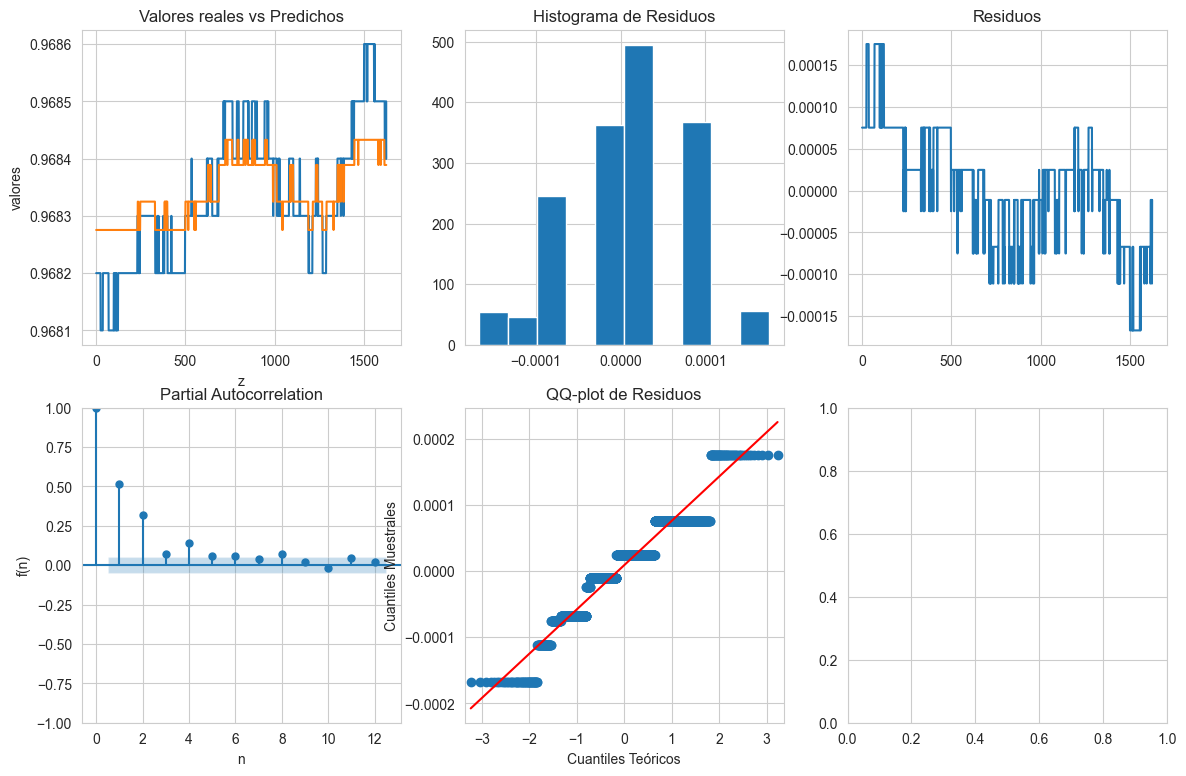

In [101]:
fig,ax=plt.subplots(2,3);fig.set_size_inches(14,9)
y1 = list(y_pred); y2 = list(xgb_model[2]['y_test'])

residuos_xgb = []
for uno, dos in zip(y1, y2):
    residuos_xgb.append(uno - dos)
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_xgb
})
ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('valores')
ax[0][0].set_xlabel('z')
plot_pacf(residuos_ridge, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')
ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])
sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

ax[0][2].plot(data['residuos'])
ax[0][2].set_title('Residuos')

In [150]:
pd.DataFrame(xgb_model[2]['metricas'])

,RMSE,MAPE,R2,Ljung-Box p-value,Jarque-Bera p-value
0,0.000068,0.00542,0.66964,0.0,1.480687e-11


## SVR

In [110]:
svr_model = training(model = 'SVR', X = X.iloc[:100000 //2], y = y.iloc[:100000//2])
if svr_model[1] is not None:
    y_pred = (svr_model[1].predict(svr_model[2]['X_test']))


"y1 = list(y_pred); y2 = list(svr_model[2]['y_test'])\nresiduos_svr = []\nfor uno, dos in zip(y1, y2):\n    residuos_svr.append(uno - dos)\ndata = pd.DataFrame({\n    'Predicciones': y1,\n    'Valores Reales': y2,\n    'residuos': residuos_svr\n})\nax[0][0].set_title('Valores reales vs Predichos')\nax[0][0].plot(data[ 'Valores Reales'],'-')\nax[0][0].plot(data['Predicciones'],'-')\nax[0][0].set_ylabel('valores')\nax[0][0].set_xlabel('z')\nplot_pacf(residuos_ridge, lags=12, ax=ax[1][0])\nax[1][0].set_ylabel('f(n)')\nax[1][0].set_xlabel('n')\nax[0][1].set_title('Histograma de Residuos')\nax[0][1].hist(data['residuos'])\nsm.qqplot(data['residuos'], line='s', ax=ax[1][1])\nax[1][1].set_title('QQ-plot de Residuos')\nax[1][1].set_xlabel('Cuantiles Teóricos')\nax[1][1].set_ylabel('Cuantiles Muestrales')\n\nax[0][2].plot(data['residuos'])\nax[0][2].set_title('Residuos')"

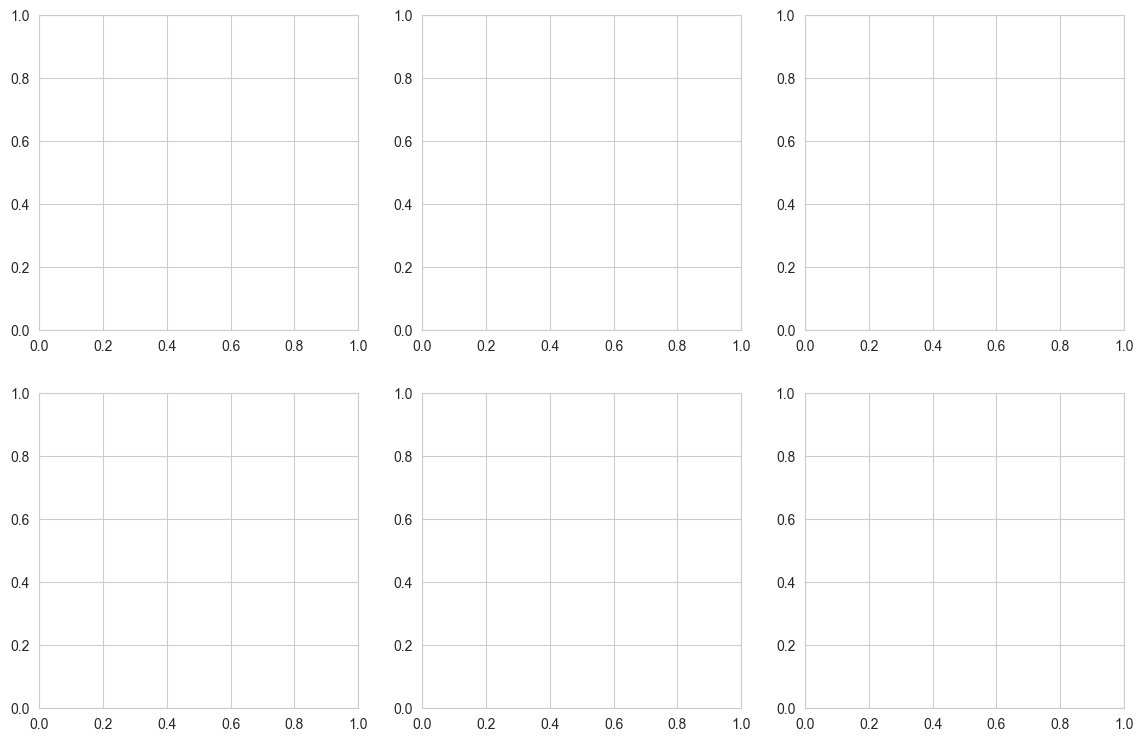

In [112]:
fig,ax=plt.subplots(2,3);fig.set_size_inches(14,9)
'''y1 = list(y_pred); y2 = list(svr_model[2]['y_test'])
residuos_svr = []
for uno, dos in zip(y1, y2):
    residuos_svr.append(uno - dos)
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_svr
})
ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('valores')
ax[0][0].set_xlabel('z')
plot_pacf(residuos_ridge, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')
ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])
sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

ax[0][2].plot(data['residuos'])
ax[0][2].set_title('Residuos')'''

For SVR we dont have a real appreciation.

In [147]:
dix_index = {
    0: 'lin', 
    1: 'knn', 
    2: 'ridge',
    3: 'rf', 
    4: 'xgb'
}
metricas_list = []
for index in range(5):
    path = f"models/{dix_index[index]}/lin-res.xlsx"
    df = pd.read_excel(path)
    y_test = df['y_test'].to_list()
    y_pred = df['y_pred'].to_list()
    df_metricas = pd.DataFrame(calcular_metricas(y_test, y_pred))
    df_metricas.insert(0, 'Modelo', dix_index[index]) 
    metricas_list.append(df_metricas)
df_metricas_apilado = pd.concat(metricas_list, ignore_index=True)
display(df_metricas_apilado)


,Modelo,RMSE,MAPE,R2,Ljung-Box p-value,Jarque-Bera p-value
0,lin,0.000021,0.001894,0.934844,0.000000e+00,9.209386e-185
1,knn,0.000014,0.000508,0.925035,0.000000e+00,0.000000e+00
2,ridge,0.000014,0.000508,0.925035,0.000000e+00,0.000000e+00
3,rf,0.000016,0.000486,0.962915,2.745677e-170,0.000000e+00
4,xgb,0.000068,0.005420,0.669640,0.000000e+00,1.480687e-11


The models exhibit varying performance levels. Linear regression (lin) performs best with a low RMSE, MAPE, 
and an R² of 0.9348. Random Forest (rf) shows strong results with an R² of 0.9629, though residual diagnostics 
indicate minor deviations. XGBoost (xgb), with the lowest R² (0.6696) and highest errors, underperforms compared 
to the other models.
